# Chandra/HETG observation of Vela X-1 (2001) — detector-space analysis

BLiSS applied to the Chandra HETG spectrum of Vela X-1 (ObsID 1927) loaded directly
from the OGIP files. HEG and MEG are analysed separately: they have different
resolutions and effective-area curves, so combining them would average two responses.

The ±1 orders of each arm were combined with CIAO:

    combine_spectra src_spectra="heg_-1.pha.gz,heg_1.pha.gz" outroot=heg \
        src_arfs="heg_-1.arf.gz,heg_1.arf.gz" src_rmfs="heg_-1.rmf.gz,heg_1.rmf.gz" \
        method=sum clobber=yes

In this mode BLiSS rebins the spectrum conserving counts, works in counts s⁻¹ keV⁻¹,
and calibrates every candidate against line-free spectra drawn as Poisson counts at
channel resolution and pushed through the same rebinning and baseline estimation as
the data. A companion notebook (`vela_x1_2001_dat.ipynb`) runs the same object from a
plain text spectrum, for comparison.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bliss import *
from bliss.line_search.blind_line_search import prepare_spectrum

config = BlindLineSearchConfig(baseline_window=0.2)
pipeline = BlindLineSearchPipeline(config=config)

## 1. Input files, output folder and energy range

In [23]:
chandra_path = Path("/Users/graciela/Desktop/git/BLiSS/examples_local/1928_lowhardness")

heg_pha = chandra_path / "vela_combo_heg_abs1.pha"
heg_rmf = chandra_path / "vela_combo_heg_abs1.rmf"
heg_arf = chandra_path / "vela_combo_heg_abs1.arf"

meg_pha = chandra_path / "vela_combo_meg_abs1.pha"
meg_rmf = chandra_path / "vela_combo_meg_abs1.rmf"
meg_arf = chandra_path / "vela_combo_meg_abs1.arf"

output_dir = Path("results_vela_x1_2001_pha")
output_dir.mkdir(exist_ok=True)

# Energy range used throughout
en1, en2 = 0.5, 3

## 2. Load and inspect the HEG spectrum

`prepare_spectrum` is the function the pipeline uses internally. With
`rebin_method="none"` it returns the spectrum at native channel resolution, already
converted to counts s⁻¹ keV⁻¹. The `.native` attribute keeps the channel-level counts
and exposure used later for the Poisson null.

channels      : 4828
exposure [s]  : 20512.063350905
median ΔE [eV]: 0.6029009819030762


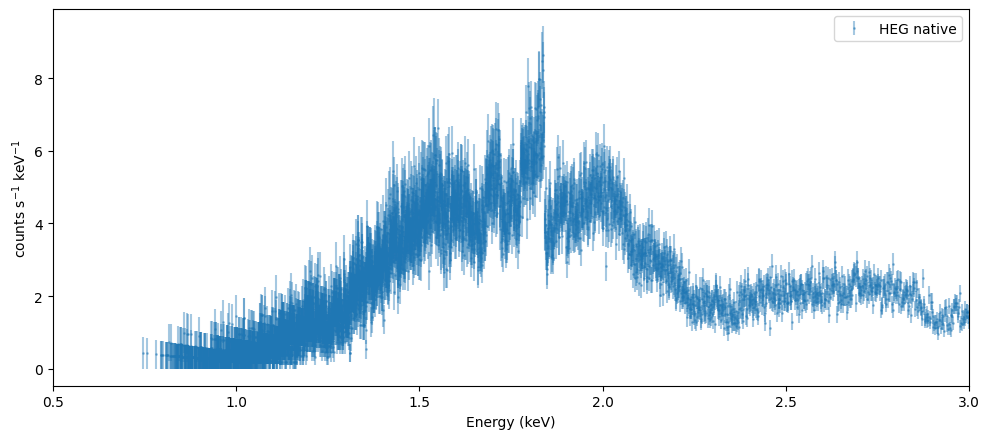

In [24]:
heg_native = prepare_spectrum(heg_pha, heg_rmf, heg_arf, rebin_method="none")

print("channels      :", len(heg_native.energy))
print("exposure [s]  :", heg_native.native.exposure)
print("median ΔE [eV]:", 1e3 * np.median(heg_native.bin_width))

plt.figure(figsize=(10, 4.5))
plt.errorbar(heg_native.energy, heg_native.values, yerr=heg_native.uncertainties,
             fmt=".", ms=2, alpha=0.4, label="HEG native")
plt.xlim(en1, en2)
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Rebin the spectrum conserving counts

Three schemes are available (`rebin_method`): `"bins"` groups a fixed number of
channels, `"resolution"` uses fixed-width intervals in keV, and `"snr"` accumulates
channels until a signal-to-noise threshold. All of them **sum** counts, so the result
stays Poisson. We use a fixed resolution of 3 eV. The same scheme will be applied to
every synthetic null realization inside the pipeline.

In [25]:
rebin_method = "resolution"
rebin_scale = 0.001   # keV

heg = prepare_spectrum(heg_pha, heg_rmf, heg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)

counts_per_bin = heg.values * heg.native.exposure * heg.bin_width
print("bins after rebinning:", len(heg.energy))
print("median counts/bin   :", np.median(counts_per_bin))

bins after rebinning: 3170
median counts/bin   : 68.00000000000001


### 3.1 Empirical baseline

The baseline is a running median in physical energy units (`baseline_window`, default
0.4 keV). It is the line-free model from which the Poisson null spectra are drawn.

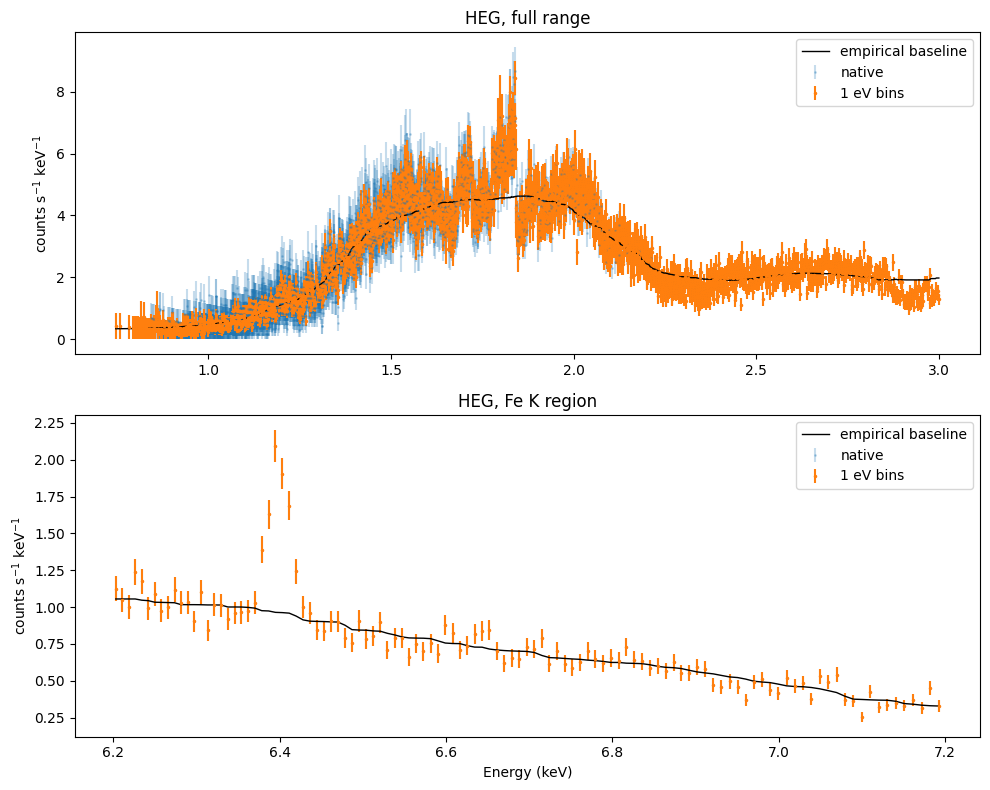

In [26]:
baseline_heg = base_calculator(heg.energy, heg.values)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, xlim, title in zip(axes, [(en1, en2), (6.2, 7.2)], ["full range", "Fe K region"]):
    m0 = (heg_native.energy >= xlim[0]) & (heg_native.energy <= xlim[1])
    m1 = (heg.energy >= xlim[0]) & (heg.energy <= xlim[1])
    ax.errorbar(heg_native.energy[m0], heg_native.values[m0], yerr=heg_native.uncertainties[m0],
                fmt=".", ms=2, alpha=0.25, label="native")
    ax.errorbar(heg.energy[m1], heg.values[m1], yerr=heg.uncertainties[m1],
                fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
    ax.plot(heg.energy[m1], baseline_heg[m1], "k-", lw=1, label="empirical baseline")
    ax.set_title(f"HEG, {title}")
    ax.set_ylabel("counts s$^{-1}$ keV$^{-1}$")
    ax.legend()
axes[1].set_xlabel("Energy (keV)")
plt.tight_layout()
plt.show()

## 4. Candidate search (HEG)

`find_candidate_lines` takes the PHA/RMF/ARF paths and the rebinning scheme, so that
the null realizations follow exactly the same chain as the data.
`num_synthetic_simulations` sets the number of null spectra.

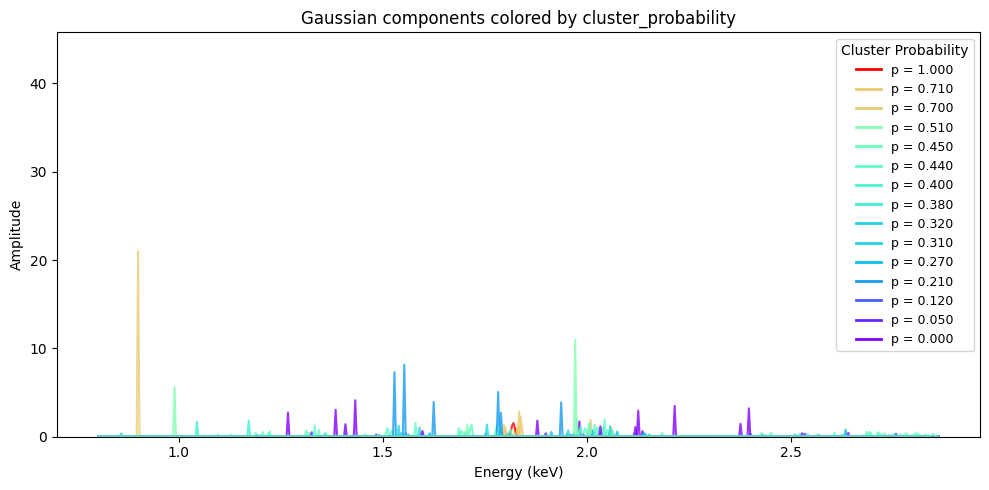

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.816552,178.722109,5.591757e-04,41.586436,0.747213,2.054545e+05,0.339589,0.389378,0.726394,0.358108,1.918989,0.000004,1.047327e-03,298.322340,0.000004,2.924610e+00,0.31
1,0.850690,2.371887,1.882099e-04,8.673965,36.634445,2.052134e+07,0.153497,0.286115,0.500359,0.367192,128.040853,0.000002,1.728311e-02,9714.108264,0.000002,4.706834e+01,0.70
2,0.857856,0.000214,1.156415e-03,0.000159,0.639123,7.478817e-02,0.455043,0.367423,0.985050,0.368931,1.739474,8.545773,1.852627e-03,0.000335,5.533049,5.021611e+00,0.31
3,0.869279,0.000000,6.903982e-12,0.000000,0.409061,0.000000e+00,-0.079126,0.262769,0.319875,0.374845,1.556731,NaN,7.079097e-12,0.000000,NaN,1.888540e-08,0.45
4,0.900372,2.906931,2.049113e-04,13.257104,23.370537,1.538757e+07,0.203849,0.235538,0.597349,0.395050,99.222026,0.000002,1.200396e-02,7941.680267,0.000002,3.038596e+01,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,2.812142,0.001638,1.479464e-03,0.001604,0.358772,3.398863e-01,0.046004,0.252954,2.201338,2.007707,1.418327,1.055565,1.330494e-03,0.001915,0.694659,6.626933e-01,0.45
239,2.829451,0.001612,2.007798e-03,0.001612,0.261240,1.816337e-01,0.054834,0.246962,2.173712,1.947717,1.057811,1.438278,1.314768e-03,0.001397,0.941402,6.750301e-01,0.45
240,2.797299,0.000000,3.139978e-04,0.000000,0.082802,0.000000e+00,0.046858,0.246962,2.223614,2.024553,0.335280,NaN,6.517111e-05,0.000000,NaN,3.219037e-02,0.44
241,2.838700,22.608892,4.045939e-04,50.259485,1.767494,8.742853e+05,0.085779,0.238815,2.281672,1.921160,7.401092,0.000002,1.792533e-03,914.203573,0.000002,9.330473e-01,0.12


In [6]:
N_SIM = 10
SEED = 1

heg_candidates = find_candidate_lines(
    pha=heg_pha, rmf=heg_rmf, arf=heg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir)

plot_line_prob(heg_candidates)
heg_candidates

## 5. Filter candidates and perform a global fit (HEG)

Candidates are kept if they pass a cluster-probability threshold, at least one
significance criterion, and a minimum relative contribution. The global
multi-Gaussian fit is done on the same rebinned spectrum used for the search.

In [7]:
P_MIN = 0.8      # minimum cluster probability (0-1)
REL_POWER_MIN = 0  # minimum relative contribution of the line (0-1)
SNR_PEAK_MIN = 0    # a line is kept if at least one S/N criterion is met
SNR_AREA_MIN = 0
SNR_AMPLITUDE_MIN = 0

lines_pd = heg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
heg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(heg_lines)} of {len(lines_pd)} candidates kept")

1 of 243 candidates kept


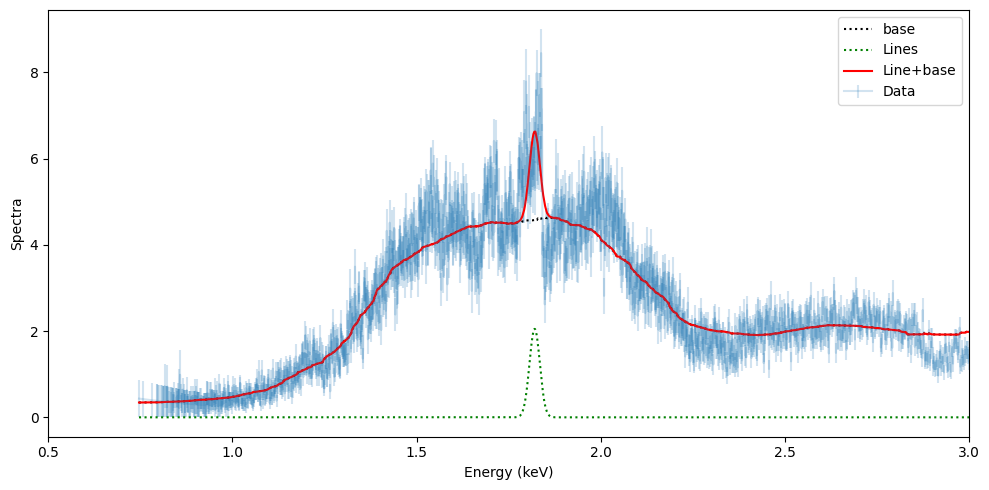

In [8]:
heg_lines_global = fit_global(
    heg_lines,
    heg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

## 6. Identify emission lines within a Doppler velocity window (HEG)

Fitted centroids are compared with a reference list of transitions. A line is
tentatively identified when its energy is consistent with a transition within the
chosen velocity window.

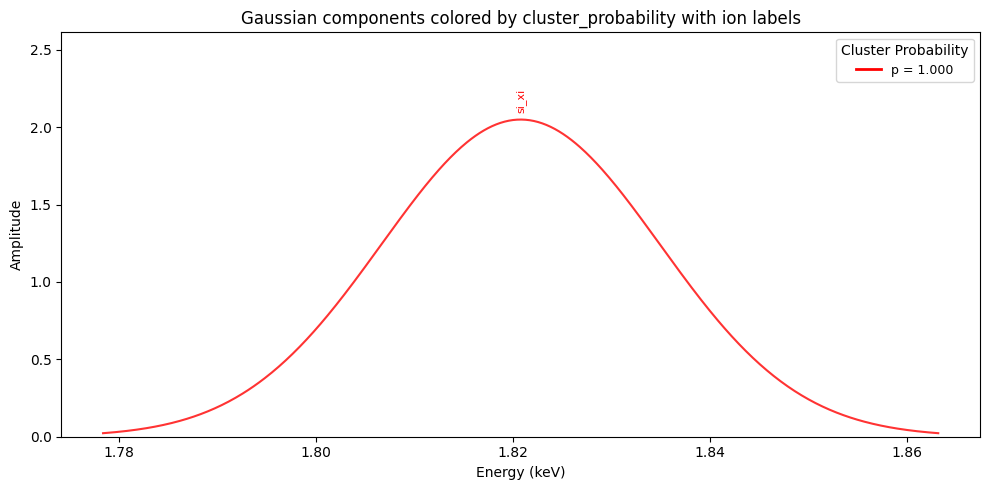

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,si_xi,-371.696239,1.820769,0.001032,0.014135,0.000982,2.049773,0.132908,0.173724,0.567628,6.496638,4.573488,3.611122,15.422442,0.072624,0.006902,10.522111,15.109302,1.0


In [9]:
max_doppler_velocity = 600  # km/s

heg_lines_ion = add_most_probable_ion(heg_lines_global, max_doppler_velocity)
plot_line_prob(heg_lines_ion)
heg_lines_ion

In [10]:
# All transitions compatible with each line within the velocity window
compatible_heg = get_all_compatible_lines(heg_lines_global, max_doppler_velocity)
compatible_heg[0].head()

,ion,energy_keV,doppler_kms
0,si_xi,1.823029,-371.696239
1,si_xi,1.823431,-437.724012
2,si_xi,1.820245,86.174821
3,si_xi,1.821449,-111.933398
4,si_xi,1.823324,-420.107413


## 7. MEG

The MEG arm has more effective area below ~2 keV but half the resolution of HEG and
almost no counts above ~5 keV. The procedure is identical.

channels: 2978  bins: 2211  exposure [s]: 20512.063350905


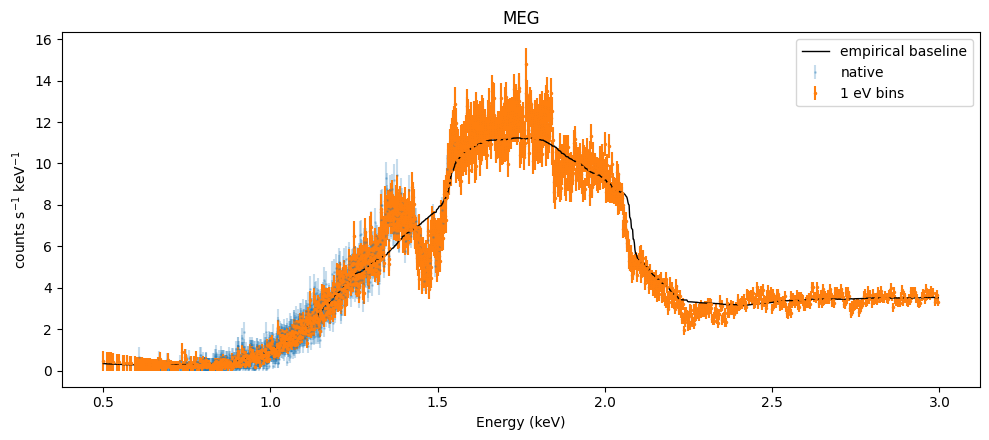

In [11]:
meg_native = prepare_spectrum(meg_pha, meg_rmf, meg_arf, rebin_method="none")
meg = prepare_spectrum(meg_pha, meg_rmf, meg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)
baseline_meg = base_calculator(meg.energy, meg.values)

print("channels:", len(meg_native.energy), " bins:", len(meg.energy),
      " exposure [s]:", meg.native.exposure)

m0 = (meg_native.energy >= en1) & (meg_native.energy <= en2)
m1 = (meg.energy >= en1) & (meg.energy <= en2)
plt.figure(figsize=(10, 4.5))
plt.errorbar(meg_native.energy[m0], meg_native.values[m0], yerr=meg_native.uncertainties[m0],
             fmt=".", ms=2, alpha=0.25, label="native")
plt.errorbar(meg.energy[m1], meg.values[m1], yerr=meg.uncertainties[m1],
             fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
plt.plot(meg.energy[m1], baseline_meg[m1], "k-", lw=1, label="empirical baseline")
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.title("MEG")
plt.legend()
plt.tight_layout()
plt.show()

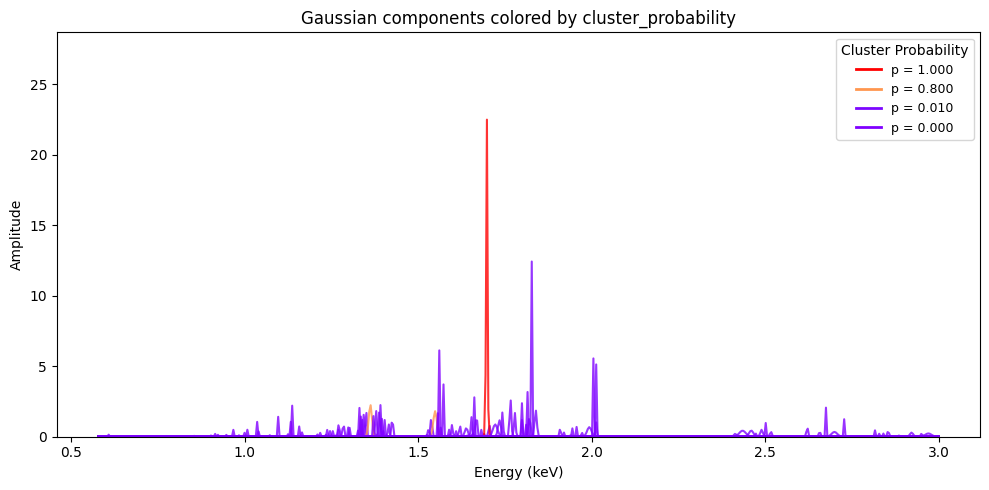

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.607064,5.742449,0.000340,6.768838,0.259383,9.466860e+03,0.220268,0.327365,0.437917,0.279822,0.792335,2.739905e-05,0.000221,9.197053,2.405852e-05,0.790744,0.00
1,0.694415,29.024863,0.000240,50.853651,0.426296,1.742050e+05,0.288800,0.212723,0.501023,0.276480,2.003995,2.447096e-06,0.000256,118.040693,2.172374e-06,0.927476,0.00
2,0.772245,0.000199,0.000390,0.008778,0.352597,1.883410e+01,0.154842,0.179985,0.406016,0.297138,1.959036,1.872123e-02,0.000345,0.019990,1.725365e-02,1.160764,0.00
3,0.800251,10.154988,0.000221,32.254965,7.409227,9.263079e+06,0.203204,0.162425,0.472677,0.313020,45.616302,7.998666e-07,0.004096,5155.785879,7.944492e-07,13.085469,0.00
4,0.838079,120.369663,0.000202,82.104083,0.585459,1.297791e+06,0.164929,0.144174,0.473707,0.339574,4.060772,4.511196e-07,0.000297,669.325390,4.437499e-07,0.874665,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2.854570,0.001876,0.001971,0.001484,0.496376,3.182226e-01,0.064162,0.229920,3.974514,3.495238,2.158904,1.559839e+00,0.002452,0.002426,1.011025e+00,0.701604,0.00
168,2.887042,218.022093,0.000785,258.694608,1.698865,2.469960e+06,0.052219,0.225886,3.897753,3.510878,7.520907,6.878105e-07,0.003341,4980.780279,6.707761e-07,0.951610,0.00
169,2.921866,0.002331,0.004588,0.002350,0.292923,1.290339e-01,0.041771,0.226474,3.807634,3.502290,1.293408,2.270126e+00,0.003369,0.002276,1.480455e+00,0.961924,0.01
170,2.950968,0.002758,0.002310,0.002477,0.232508,2.158198e-01,0.029254,0.221716,3.735997,3.523623,1.048673,1.077324e+00,0.001347,0.001909,7.052230e-01,0.382151,0.00


In [12]:
meg_candidates = find_candidate_lines(
    pha=meg_pha, rmf=meg_rmf, arf=meg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir,
)
plot_line_prob(meg_candidates)
meg_candidates

In [13]:
lines_pd = meg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
meg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(meg_lines)} of {len(lines_pd)} candidates kept")

3 of 172 candidates kept


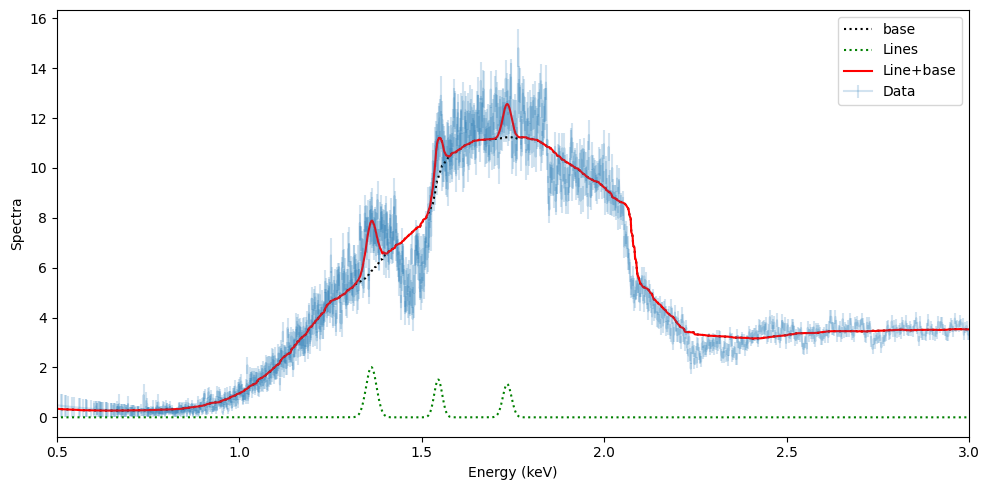

In [14]:
meg_lines_global = fit_global(
    meg_lines,
    meg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

In [15]:
meg_lines_global

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,1.361566,0.001188,0.014516,0.001174,2.010381,0.144124,0.093262,0.627916,7.073510,5.866684,3.201673,13.948931,0.073151,0.007907,9.251719,11.919595,1.0
1,1.544865,0.001641,0.011019,0.001604,1.513688,0.201085,0.028805,0.711291,10.337453,9.758584,2.128084,7.527609,0.041809,0.008240,5.074116,4.184960,1.0
2,1.733910,0.002102,0.011998,0.002087,1.332659,0.205354,0.000000,0.700187,11.154972,11.154972,1.903290,6.489581,0.040081,0.009314,4.303083,3.397894,1.0
